<a href="https://colab.research.google.com/github/nermeenrashad/churn-prediction-project/blob/main/Customer_Churn_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd
import numpy as np

df = pd.read_csv('ecommerce_customer_churn_dataset.csv')

print("Data Shape:", df.shape)
print("\nData Preview:")
print(df.head())
print("\nData Info:")
print(df.info())

Data Shape: (50000, 25)

Data Preview:
    Age  Gender Country        City  Membership_Years  Login_Frequency  \
0  43.0    Male  France   Marseille               2.9             14.0   
1  36.0    Male      UK  Manchester               1.6             15.0   
2  45.0  Female  Canada   Vancouver               2.9             10.0   
3  56.0  Female     USA    New York               2.6             10.0   
4  35.0    Male   India       Delhi               3.1             29.0   

   Session_Duration_Avg  Pages_Per_Session  Cart_Abandonment_Rate  \
0                  27.4                6.0                   50.6   
1                  42.7               10.3                   37.7   
2                  24.8                1.6                   70.9   
3                  38.4               14.8                   41.7   
4                  51.4                NaN                   19.1   

   Wishlist_Items  ...  Email_Open_Rate  Customer_Service_Calls  \
0             3.0  ...            

In [3]:
from sklearn.preprocessing import LabelEncoder
from sklearn.impute import SimpleImputer

X = df.drop(columns=['Churned'])
y = df['Churned']

num_cols = X.select_dtypes(include=['float64', 'int64']).columns
cat_cols = X.select_dtypes(include=['object']).columns

X[num_cols] = SimpleImputer(strategy='median').fit_transform(X[num_cols])

for col in cat_cols:
    X[col] = LabelEncoder().fit_transform(X[col].astype(str))

In [4]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

            Model Accuracy Precision Recall F1-Score
    Decision Tree   88.88%    86.43% 72.98%   79.14%
    Random Forest   91.55%    92.27% 77.23%   84.08%
Gradient Boosting   92.15%    92.18% 79.58%   85.42%


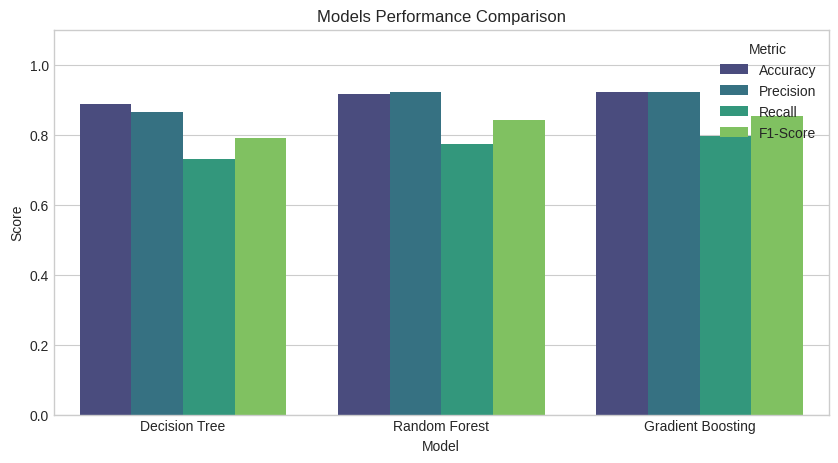

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

models = {
    "Decision Tree": DecisionTreeClassifier(max_depth=10, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, max_depth=15, random_state=42, n_jobs=-1),
    "Gradient Boosting": GradientBoostingClassifier(n_estimators=150, learning_rate=0.1, max_depth=6, random_state=42)
}

results = []
for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, zero_division=0),
        "Recall": recall_score(y_test, y_pred, zero_division=0),
        "F1-Score": f1_score(y_test, y_pred, zero_division=0)
    })

comparison_df = pd.DataFrame(results)

formatted_df = comparison_df.copy()
for col in ['Accuracy', 'Precision', 'Recall', 'F1-Score']:
    formatted_df[col] = formatted_df[col].apply(lambda x: f"{x * 100:.2f}%")

print(formatted_df.to_string(index=False))

plt.figure(figsize=(10, 5))
df_melted = comparison_df.melt(id_vars="Model", var_name="Metric", value_name="Score")
sns.barplot(data=df_melted, x="Model", y="Score", hue="Metric", palette="viridis")
plt.ylim(0, 1.1)
plt.title("Models Performance Comparison")
plt.show()

In [6]:
best_model = models["Gradient Boosting"]
predictions = best_model.predict(X_test_scaled[:10])

for idx, pred in enumerate(predictions):
    status = "At Risk (Churn)" if pred == 1 else "Active Customer"
    print(f"Customer #{idx + 1}: {status}")

Customer #1: Active Customer
Customer #2: Active Customer
Customer #3: Active Customer
Customer #4: Active Customer
Customer #5: Active Customer
Customer #6: Active Customer
Customer #7: Active Customer
Customer #8: Active Customer
Customer #9: Active Customer
Customer #10: At Risk (Churn)


In [7]:
from sklearn.metrics.pairwise import cosine_similarity

rec_features = ['Average_Order_Value', 'Total_Purchases', 'Discount_Usage_Rate', 'Wishlist_Items']
scaled_rec_data = StandardScaler().fit_transform(X[rec_features])

customer_id = 0
status = predictions[customer_id]

print(f"Customer #{customer_id + 1} Status: {'At Risk' if status == 1 else 'Active'}")

if status == 1:
    similarity_scores = cosine_similarity(scaled_rec_data[customer_id:customer_id+1], scaled_rec_data[:500])[0]
    matched_peer = np.argsort(similarity_scores)[-2]
    print("Action Plan: Send 20% discount coupon for Wishlist items.")
else:
    print("Action Plan: Recommend complementary products (Cross-selling).")

Customer #1 Status: Active
Action Plan: Recommend complementary products (Cross-selling).


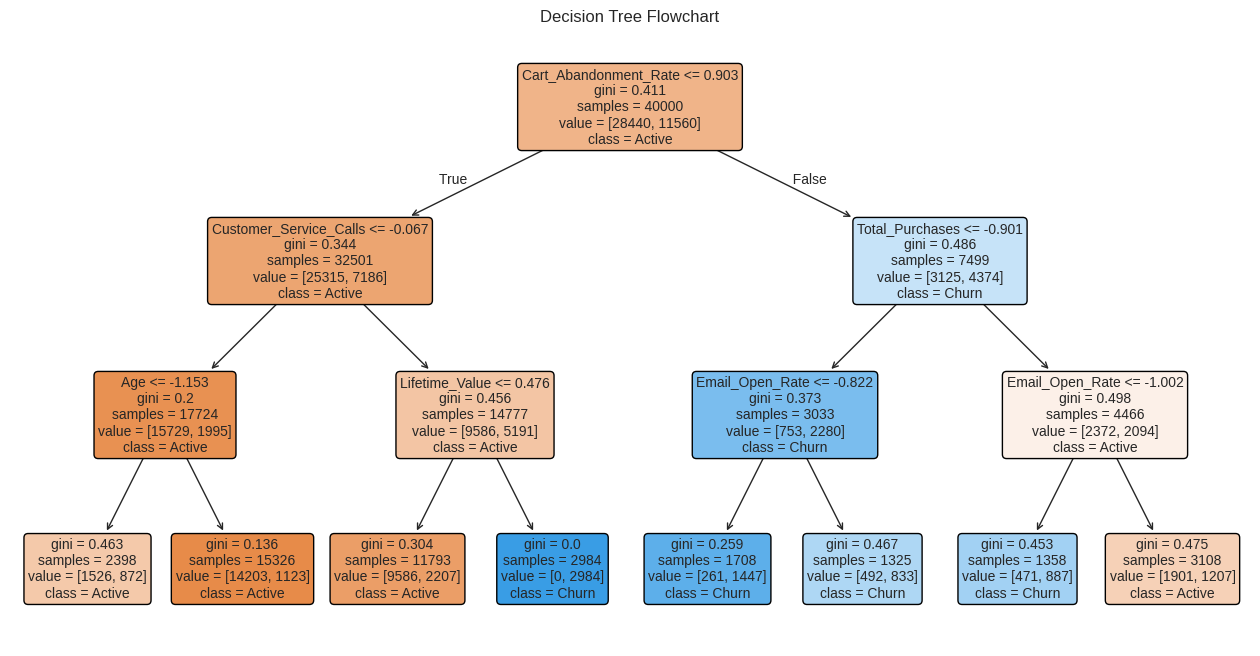

In [8]:
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier, plot_tree

dt_vis = DecisionTreeClassifier(max_depth=3, random_state=42)
dt_vis.fit(X_train_scaled, y_train)

plt.figure(figsize=(16, 8))
plot_tree(dt_vis, feature_names=X.columns, class_names=['Active', 'Churn'], filled=True, rounded=True, fontsize=10)
plt.title("Decision Tree Flowchart")
plt.show()

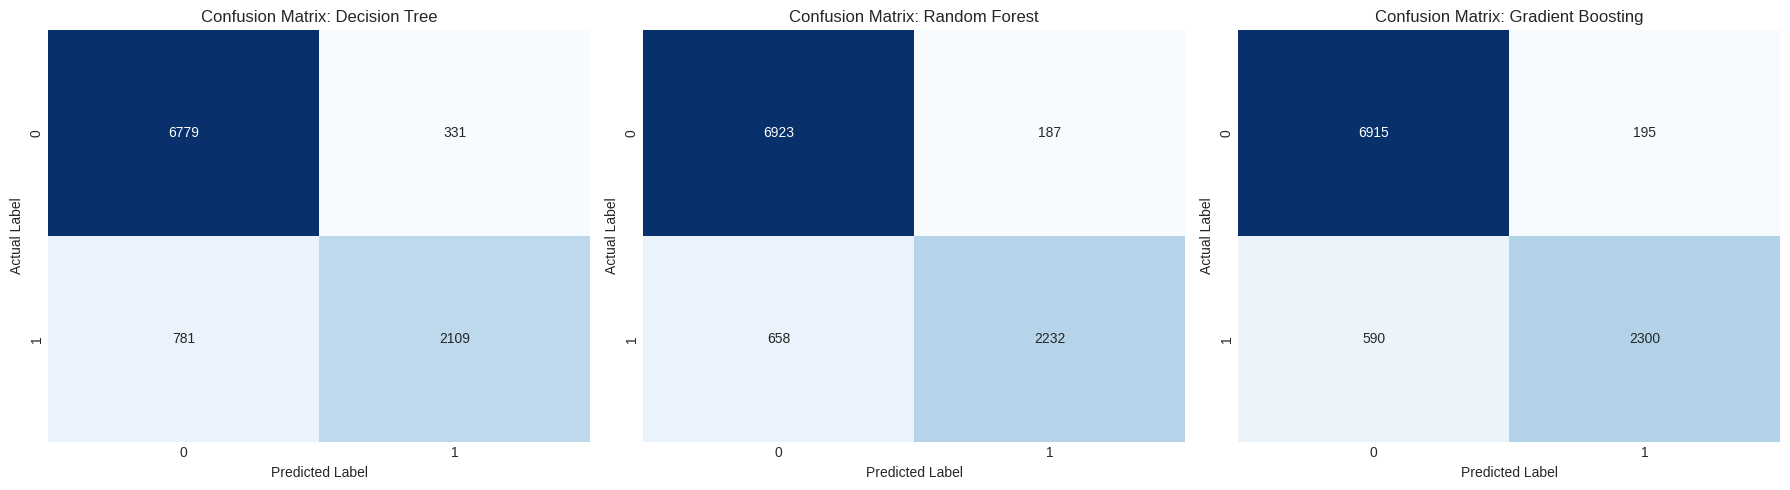

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, (name, model) in enumerate(models.items()):
    y_pred = model.predict(X_test_scaled)
    cm = confusion_matrix(y_test, y_pred)

    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i], cbar=False)
    axes[i].set_title(f"Confusion Matrix: {name}")
    axes[i].set_xlabel("Predicted Label")
    axes[i].set_ylabel("Actual Label")

plt.tight_layout()
plt.show()